## Exercise 4 (1 point)
Create a visualization MCP server, with line_plot endpoint. It should create a line plot from given data using Matplotlib and return it as an image, encoded with base64.

Required parameters: data, one or more lists of numbers Optional parameters: title, x_label, y_label, and legend (bool, whether to show legend)

Test it with sample data. You can decode the image and save it to disk.

In [ ]:
import base64
import json
import os
from contextlib import AsyncExitStack

from dotenv import load_dotenv
from IPython.display import Image, display
from mcp import ClientSession
from mcp.client.streamable_http import streamable_http_client
from openai import OpenAI

load_dotenv(override=True)

API_KEY = os.getenv("GEMINI_API_KEY")
MODEL = "gemini-3.1-flash-lite-preview"  # test phase when I was doing it (i.e. in May) so there were lots of tokens. It is not true anymore :(


In [2]:
class MCPManager:
    def __init__(self, servers: dict[str, str]):
        self.servers = servers
        self.clients = {}
        self.tools = []
        self._stack = AsyncExitStack()

    async def __aenter__(self):
        for url in self.servers.values():
            read, write, session_id = await self._stack.enter_async_context(
                streamable_http_client(url)
            )
            session = await self._stack.enter_async_context(ClientSession(read, write))
            await session.initialize()

            tools_resp = await session.list_tools()
            for t in tools_resp.tools:
                self.clients[t.name] = session
                self.tools.append(
                    {
                        "type": "function",
                        "function": {
                            "name": t.name,
                            "description": t.description,
                            "parameters": t.inputSchema,
                        },
                    }
                )

        return self

    async def __aexit__(self, exc_type, exc_val, exc_tb):
        await self._stack.aclose()

    async def call_tool(self, name: str, args: dict) -> str:
        result = await self.clients[name].call_tool(name, arguments=args)
        return result.content[0].text


async def make_llm_request_mcp(prompt: str) -> str:
    mcp_servers = {
        "visualization": "http://localhost:8003/mcp",
    }

    client = OpenAI(
        api_key=API_KEY,
        base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
    )

    async with MCPManager(mcp_servers) as mcp:
        messages = [
            {
                "role": "system",
                "content": "You are a helpful assistant. Use tools if you need to.",
            },
            {"role": "user", "content": prompt},
        ]

        for _ in range(10):
            response = client.chat.completions.create(
                model=MODEL,
                messages=messages,
                tools=mcp.tools,
                tool_choice="auto",
                max_completion_tokens=1000,
            )

            resp_message = response.choices[0].message
            if not resp_message.tool_calls:
                return resp_message.content

            messages.append(
                {k: v for k, v in resp_message.model_dump().items() if v is not None}
            )
            for tool_call in resp_message.tool_calls:
                func_name = tool_call.function.name
                func_args = json.loads(tool_call.function.arguments)

                print(f"Executing tool '{func_name}' with args:")
                print(json.dumps(func_args, indent=2))

                func_result = await mcp.call_tool(func_name, func_args)

                if func_name == "line_plot":
                    display(Image(data=base64.b64decode(func_result)))
                    tool_content = "Plot generated and displayed successfully."
                else:
                    tool_content = func_result

                messages.append(
                    {
                        "role": "tool",
                        "tool_call_id": tool_call.id,
                        "name": func_name,
                        "content": tool_content,
                    }
                )


Executing tool 'line_plot' with args:
{
  "x_label": "x (radians)",
  "title": "sin(x) for 10 points between 0 and pi",
  "data": [
    [
      0,
      0.342,
      0.643,
      0.866,
      0.985,
      0.985,
      0.866,
      0.643,
      0.342,
      0
    ]
  ],
  "x_data": [
    0,
    0.349,
    0.698,
    1.047,
    1.396,
    1.745,
    2.094,
    2.443,
    2.793,
    3.142
  ],
  "y_label": "sin(x)"
}


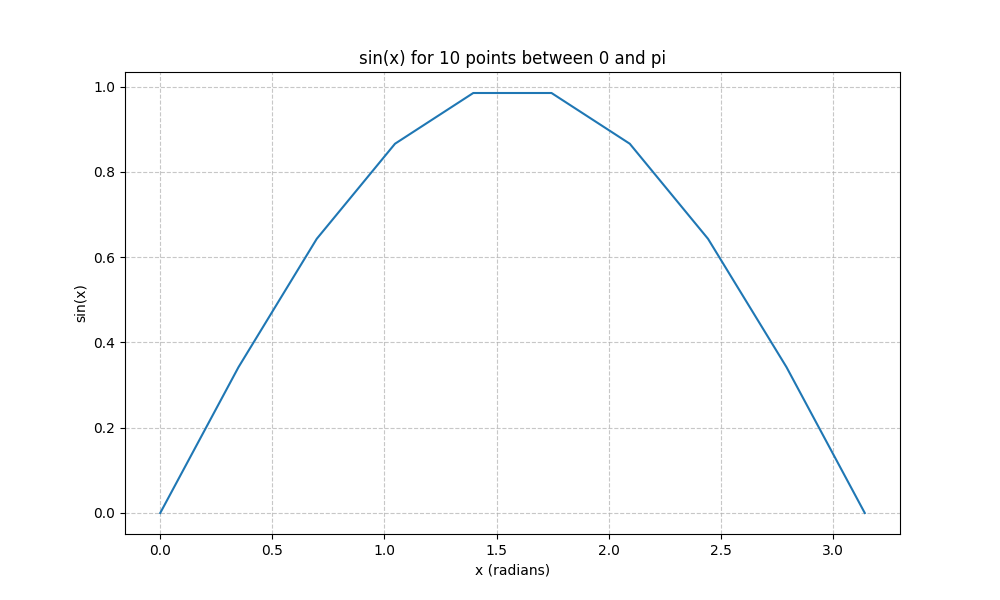

Response: The plot above displays $\sin(x)$ calculated at 10 discrete points, ranging from $0$ to $\pi$ (approximately 3.142 radians).

Executing tool 'line_plot' with args:
{
  "x_data": [
    1,
    2,
    3,
    4,
    5
  ],
  "x_label": "x",
  "title": "Plot of x^2",
  "y_label": "x^2",
  "data": [
    [
      1,
      4,
      9,
      16,
      25
    ]
  ]
}


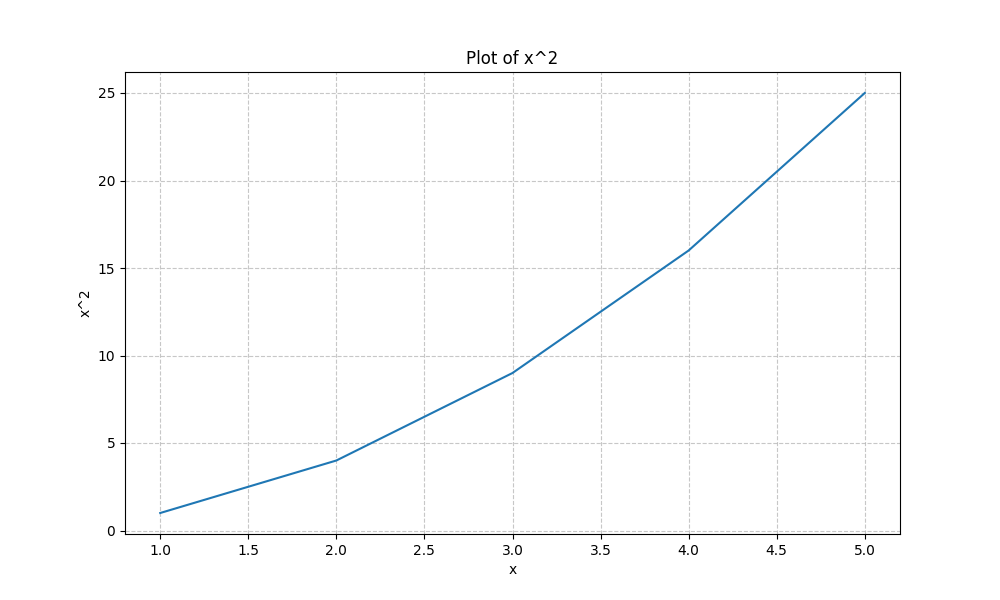

Response: The plot for $x^2$ with $x = [1, 2, 3, 4, 5]$ has been generated.


In [3]:
prompt = "Plot sin(x) using only 10 discrete x points."
response = await make_llm_request_mcp(prompt)
print("Response:", response)

print()

prompt = "Plot x^2 for these x values: [1, 2, 3, 4, 5]."
response = await make_llm_request_mcp(prompt)
print("Response:", response)
